# Notebook 5 — Stop Clustering

In [4]:
import os
import warnings
from pathlib import Path
from urllib.parse import quote_plus

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sqlalchemy import create_engine, text

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-darkgrid")

In [5]:
env_path = Path("../.env")
load_dotenv(env_path)

db_user = quote_plus(os.getenv("DB_USER", ""))
db_password = quote_plus(os.getenv("DB_PASSWORD", ""))
db_host = os.getenv("DB_HOST", "localhost")
db_port = os.getenv("DB_PORT", "5432")
db_name = os.getenv("DB_NAME", "transitpulse")

engine = create_engine(
    f"postgresql+psycopg2://{db_user}:{db_password}@{db_host}:{db_port}/{db_name}"
)
model_dir = Path("../models")
model_dir.mkdir(exist_ok=True)
print("Database engine and models directory are ready.")

Database engine and models directory are ready.


In [6]:
print("Loading stop-level ridership and delay profiles...")
stop_query = text("""
SELECT
    s.stop_id,
    s.stop_name,
    s.latitude,
    s.longitude,
    s.is_interchange,
    s.is_terminal,
    COUNT(f.ridership_id) AS trip_count,
    SUM(f.passenger_count) AS total_passengers,
    AVG(f.passenger_count) AS avg_passengers_per_trip,
    AVG(f.delay_minutes) AS avg_delay,
    MAX(f.delay_minutes) AS max_delay,
    STDDEV(f.passenger_count) AS passenger_stddev
FROM dim_stop s
LEFT JOIN fact_ridership f ON s.stop_id = f.stop_id
GROUP BY s.stop_id, s.stop_name, s.latitude, s.longitude, s.is_interchange, s.is_terminal
ORDER BY s.stop_id
""")
df_stops = pd.read_sql(stop_query, engine)
has_coordinates = df_stops["latitude"].notna() & df_stops["longitude"].notna()
df_stops = df_stops.fillna(0)
print(f"Stop data shape: {df_stops.shape}")
df_stops.head()

Loading stop-level ridership and delay profiles...
Stop data shape: (167, 12)


,stop_id,stop_name,latitude,longitude,is_interchange,is_terminal,trip_count,total_passengers,avg_passengers_per_trip,avg_delay,max_delay,passenger_stddev
0,1,AMPANG,3.150318,101.760049,False,False,3056,216726,70.918194,10.045298,29.46,79.529722
1,2,CAHAYA,3.140575,101.756677,False,False,3084,218398,70.816472,10.272853,29.80,78.757708
2,3,CEMPAKA,3.138324,101.752979,False,False,3001,213390,71.106298,10.000780,29.50,79.634505
3,4,PANDAN INDAH,3.134581,101.746509,False,False,2947,214400,72.751951,10.030048,28.70,81.029802
4,5,PANDAN JAYA,3.130141,101.739122,False,False,3019,213556,70.737330,10.095220,29.24,79.550416


In [7]:
print("Scaling stop profile features...")
features = [
    "trip_count", "total_passengers", "avg_passengers_per_trip", "avg_delay",
    "max_delay", "passenger_stddev", "is_interchange", "is_terminal"
]
df_stops[["is_interchange", "is_terminal"]] = df_stops[[
    "is_interchange", "is_terminal"
]].astype(int)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_stops[features])
print(f"Scaled {len(features)} features for {len(df_stops):,} stops.")

Scaling stop profile features...
Scaled 8 features for 167 stops.


Calculating KMeans inertia for K=2 through K=10...


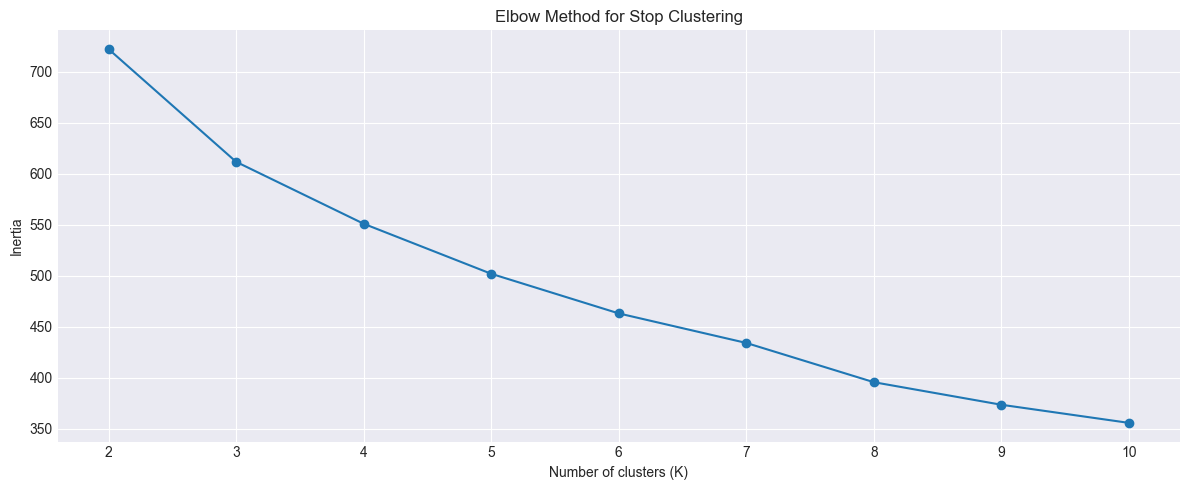

Best K appears to be around 4.


In [8]:
print("Calculating KMeans inertia for K=2 through K=10...")
k_values = range(2, 11)
inertias = []
for k in k_values:
    candidate_model = KMeans(n_clusters=k, random_state=42, n_init=10)
    candidate_model.fit(X_scaled)
    inertias.append(candidate_model.inertia_)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(list(k_values), inertias, marker="o")
ax.set_title("Elbow Method for Stop Clustering")
ax.set_xlabel("Number of clusters (K)")
ax.set_ylabel("Inertia")
ax.set_xticks(list(k_values))
fig.tight_layout()
fig.savefig(model_dir / "clustering_elbow.png", dpi=150, bbox_inches="tight")
plt.show()
print("Best K appears to be around 4.")

In [9]:
print("Fitting the four-cluster KMeans model...")
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_stops["cluster"] = kmeans.fit_predict(X_scaled)
silhouette = silhouette_score(X_scaled, df_stops["cluster"])
print(f"Silhouette score: {silhouette:.4f}")

Fitting the four-cluster KMeans model...
Silhouette score: 0.1810


In [10]:
print("Profiling clusters and assigning descriptive labels...")
cluster_profile = df_stops.groupby("cluster")[features].mean()
display(cluster_profile)

traffic_rank = cluster_profile["total_passengers"].rank(method="first")
high_traffic_clusters = set(traffic_rank.nlargest(2).index)
low_traffic_clusters = set(cluster_profile.index) - high_traffic_clusters

high_delay_prone = cluster_profile.loc[list(high_traffic_clusters), "avg_delay"].idxmax()
high_reliable = (high_traffic_clusters - {high_delay_prone}).pop()
low_delay_prone = cluster_profile.loc[list(low_traffic_clusters), "avg_delay"].idxmax()
low_reliable = (low_traffic_clusters - {low_delay_prone}).pop()

cluster_labels = {
    high_reliable: "High Traffic — Reliable",
    high_delay_prone: "High Traffic — Delay Prone",
    low_reliable: "Low Traffic — Reliable",
    low_delay_prone: "Low Traffic — Delay Prone",
}
df_stops["cluster_label"] = df_stops["cluster"].map(cluster_labels)
print(cluster_labels)

Profiling clusters and assigning descriptive labels...


,trip_count,total_passengers,avg_passengers_per_trip,avg_delay,max_delay,passenger_stddev,is_interchange,is_terminal
cluster,,,,,,,,
0,2925.767442,207404.186047,70.892193,9.981886,29.539070,79.567503,0.0,0.0
1,3001.551724,215822.862069,71.906600,9.998242,29.202759,80.087042,0.0,0.0
2,3019.926829,221619.390244,73.389727,9.993209,29.598293,81.830804,0.0,0.0
3,3024.629630,214213.185185,70.824261,10.018171,29.667593,79.178735,0.0,0.0


{2: 'High Traffic — Reliable', np.int32(1): 'High Traffic — Delay Prone', 0: 'Low Traffic — Reliable', np.int32(3): 'Low Traffic — Delay Prone'}


Plotting the cluster distribution...


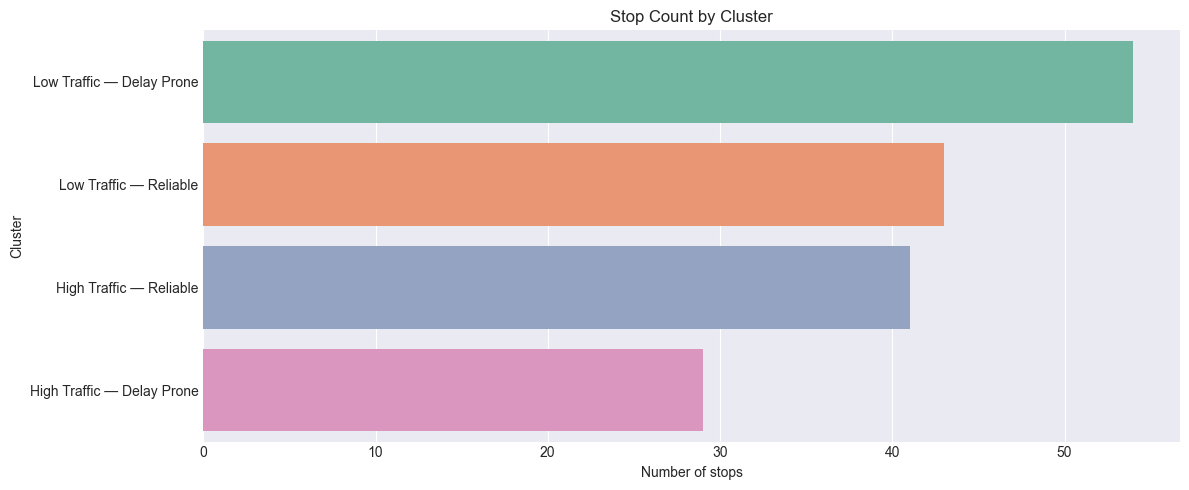

In [11]:
print("Plotting the cluster distribution...")
cluster_order = df_stops["cluster_label"].value_counts().index
fig, ax = plt.subplots(figsize=(12, 5))
sns.countplot(data=df_stops, y="cluster_label", order=cluster_order, palette="Set2", ax=ax)
ax.set_title("Stop Count by Cluster")
ax.set_xlabel("Number of stops")
ax.set_ylabel("Cluster")
fig.tight_layout()
fig.savefig(model_dir / "cluster_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

Plotting passenger volume against average delay...


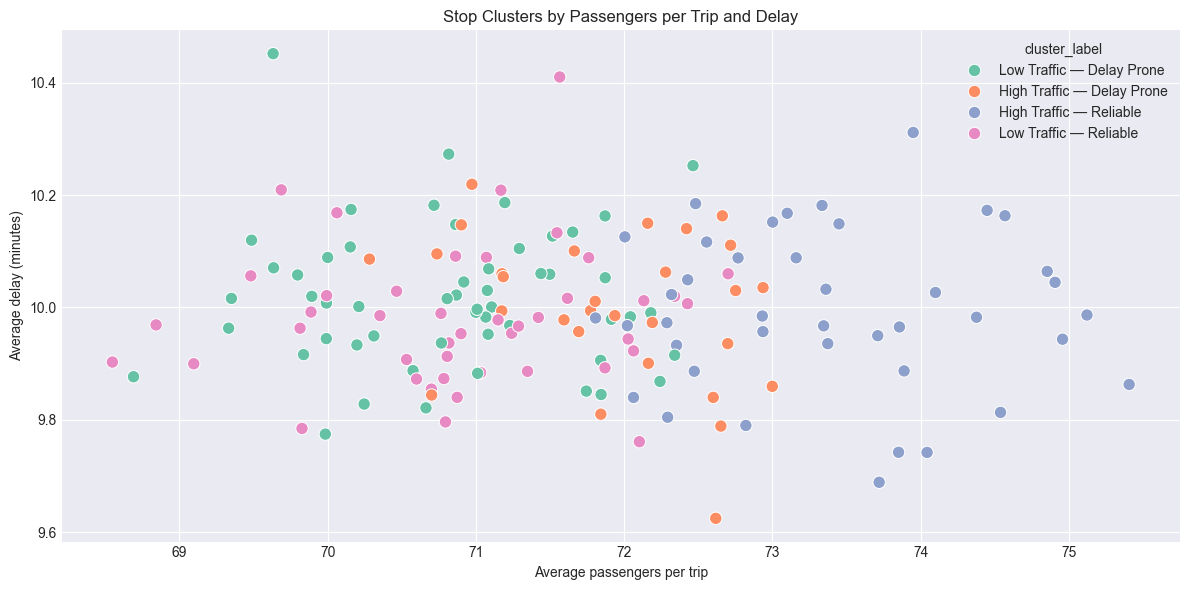

In [12]:
print("Plotting passenger volume against average delay...")
fig, ax = plt.subplots(figsize=(12, 6))
sns.scatterplot(
    data=df_stops, x="avg_passengers_per_trip", y="avg_delay",
    hue="cluster_label", palette="Set2", s=80, ax=ax
)
ax.set_title("Stop Clusters by Passengers per Trip and Delay")
ax.set_xlabel("Average passengers per trip")
ax.set_ylabel("Average delay (minutes)")
fig.tight_layout()
fig.savefig(model_dir / "cluster_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

Plotting geographic stop clusters...


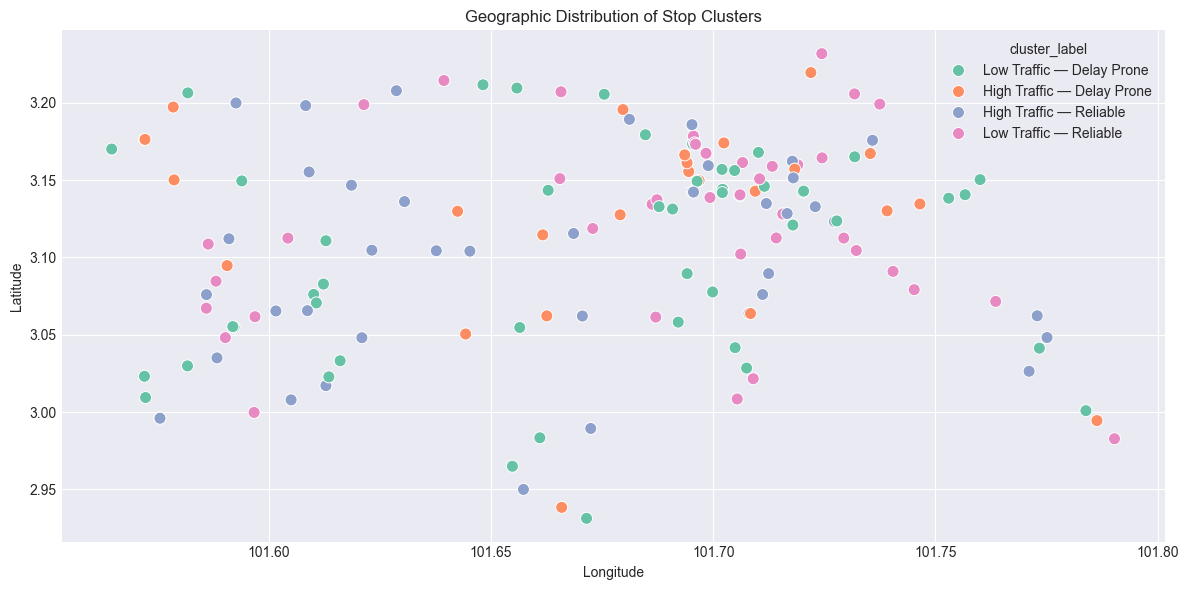

In [13]:
print("Plotting geographic stop clusters...")
mapped_stops = df_stops.loc[has_coordinates].copy()
fig, ax = plt.subplots(figsize=(12, 6))
sns.scatterplot(
    data=mapped_stops, x="longitude", y="latitude",
    hue="cluster_label", palette="Set2", s=75, ax=ax
)
ax.set_title("Geographic Distribution of Stop Clusters")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
fig.tight_layout()
fig.savefig(model_dir / "cluster_map.png", dpi=150, bbox_inches="tight")
plt.show()

In [14]:
print("Saving cluster assignments and the fitted KMeans model...")
df_stops[[
    "stop_id", "stop_name", "cluster", "cluster_label", "total_passengers", "avg_delay"
]].to_csv(model_dir / "stop_clusters.csv", index=False)
joblib.dump(kmeans, model_dir / "stop_kmeans.pkl")
print("Cluster results saved.")

Saving cluster assignments and the fitted KMeans model...
Cluster results saved.


## Summary

KMeans groups stops with similar traffic volume, passenger variability, delay behavior, and operational roles. The four descriptive labels distinguish high- and low-traffic stops, then separate the more reliable cluster from the more delay-prone cluster within each traffic tier. The silhouette score indicates how clearly the profiles separate, while the distribution, profile scatter, and geographic map reveal how each stop segment behaves and where it occurs.